In [75]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import random
from sklearn.metrics import calinski_harabasz_score, silhouette_score

In [58]:
class Matrix:
  def __init__(self, matrix: list[list[float]]):
    self.matrix: list[list[float]] = matrix
    self.rows: int = len(matrix)
    self.columns: int = len(matrix[0])


  def __getitem__(self, index):
    return self.matrix[index]


  def __setitem__(self, index, value):
    self.matrix[index] = value


  def __add__(self, other):
    if self.rows != other.rows or self.columns != other.columns:
      raise ValueError("Incorrect dimensions")

    result = [[0]*self.columns for _ in range(self.rows)]

    for i in range(self.rows):
      for j in range(self.columns):
        result[i][j] = self.matrix[i][j] + other.matrix[i][j]

    return Matrix(result)


  def __sub__(self, other):
    if self.rows != other.rows or self.columns != other.columns:
      raise ValueError("Incorrect dimensions")

    return self + (-1) * other


  def __mul__(self, scalar):
    result = [[0]*self.columns for _ in range(self.rows)]

    for i in range(self.rows):
      for j in range(self.columns):
        result[i][j] = self.matrix[i][j] * scalar

    return Matrix(result)


  def __rmul__(self, scalar):
    return self * scalar


  def __matmul__(self, other):
    if self.columns != other.rows:
      raise ValueError("Incorrect dimensions")

    result = [[0]*other.columns for _ in range(self.rows)]
    for i in range(self.rows):
      for j in range(other.columns):
        result[i][j] = sum(self[i][k] * other[k][j] for k in range(self.columns))

    return Matrix(result)


  def __pow__(self, power):
    result = [
        [val ** power for val in row]
        for row in self.matrix
    ]

    return Matrix(result)


  def __eq__(self, other):
    if (self.rows != other.rows or self.columns != other.columns):
      return False

    for i in range(self.rows):
      for j in range(self.columns):
        if self[i][j] != other[i][j]:
          return False

    return True


  def __str__(self):
    result = []
    for row in self.matrix:
      formatted_row = " ".join(f"{val:8.3f}" for val in row)
      result.append(formatted_row)

    return "\n".join(result)


  def copy(self):
    return Matrix([
        [val for val in row]
        for row in self.matrix
    ])


  def swap_rows(self, i, j):
    self.matrix[i], self.matrix[j] = self.matrix[j], self.matrix[i]


  def div_row(self, row_index, scalar):
    for i in range(self.columns):
      self.matrix[row_index][i] /= scalar


  def add_rows(self, pivot_row, row, scalar):
    for i in range(self.columns):
      self.matrix[row][i] += self.matrix[pivot_row][i] * scalar


  @property
  def T(self):
    result = [[0]*self.rows for _ in range(self.columns)]

    for i in range(self.rows):
      for j in range(self.columns):
        result[j][i] = self[i][j]

    return Matrix(result)


  def det(self):
    self_copy = self.copy()
    det_sign = 1.0

    for i in range(self_copy.rows):
      max_in_column = 0.0
      max_row_index = i

      for j in range(i, self_copy.rows):
        if abs(self_copy[j][i]) > max_in_column:
          max_in_column = abs(self_copy[j][i])
          max_row_index = j

      if max_in_column < 1e-5:
        return 0.0

      if max_row_index != i:
        self_copy.swap_rows(i, max_row_index)
        det_sign *= -1.0

      pivot = self_copy[i][i]

      for j in range(i + 1, self_copy.rows):
        if self_copy[j][i] != 0:
          factor = self_copy[j][i] / pivot
          self_copy.add_rows(i, j, -factor)

    deter = det_sign
    for i in range(self_copy.rows):
      deter *= self_copy[i][i]

    return deter


  @staticmethod
  def eye(n):
    return Matrix([
        [1 if i == j else 0 for i in range(n)]
        for j in range(n)
    ])


  def tracer(self):
    result = 0
    for i in range(self.rows):
      result += self[i][i]
    return result


  def norm(self):
    return sum(val**2 for row in self.matrix for val in row) ** 0.5


# **EASY**

In [59]:
def make_augmented_matrix(A: 'Matrix', b: 'Matrix') -> 'Matrix':
  if A.rows != b.rows:
    raise ValueError("Incorrect dimensions")

  result = []

  for i in range(A.rows):
    result.append(A.matrix[i] + [b[i][0]])

  return Matrix(result)


In [81]:
def gauss_solver(A: 'Matrix', b: 'Matrix') -> List['Matrix']:
  if A.rows != A.columns or A.rows != b.rows:
    raise ValueError("Incorrect dimensions")

  M = make_augmented_matrix(A, b)

  current_row = 0
  pivot_columns = []

  for column in range(A.columns):
    if current_row >= M.rows:
      break

    max_in_column = 0.0
    max_row_index = current_row

    for j in range(current_row, M.rows):
      if abs(M[j][column]) > max_in_column:
        max_in_column = abs(M[j][column])
        max_row_index = j

    if max_in_column < 1e-5:
      continue

    M.swap_rows(current_row, max_row_index)
    M.div_row(current_row, M[current_row][column])

    for j in range(current_row + 1, M.rows):
      if M[j][column] != 0:
        M.add_rows(current_row, j, -M[j][column])

    pivot_columns.append(column)
    current_row += 1

    is_zero_vector = all(abs(b[i][0]) < 1e-10 for i in range(b.rows))

    if len(pivot_columns) == A.columns and is_zero_vector:
        pivot_columns.pop(-1)
        current_row -= 1

    for i in range(current_row, M.rows):
        if abs(M[i][A.columns]) > 1e-5:
            raise ValueError("System is inconsistent")

  for i in range(current_row, M.rows):
    if abs(M[i][A.columns]) > 1e-5:
      raise ValueError("System is inconsistent")

  for i in range(current_row - 1, -1, -1):
    pivot_col_idx = pivot_columns[i]
    for k in range(i - 1, -1, -1):
      if M[k][pivot_col_idx] != 0:
        M.add_rows(i, k, -M[k][pivot_col_idx])

  free_columns = [col for col in range(A.columns) if col not in pivot_columns]
  solutions = []

  if len(free_columns) == 0:
    solution_data = [[0.0] for _ in range(A.columns)]
    for i in range(current_row):
      col_idx = pivot_columns[i]
      solution_data[col_idx][0] = M[i][A.columns]
    solutions.append(Matrix(solution_data))

  else:
    for free_col_idx in free_columns:
      vector_data = [[0.0] for _ in range(A.columns)]
      vector_data[free_col_idx][0] = 1.0

      for i in range(current_row):
        col_idx = pivot_columns[i]
        vector_data[col_idx][0] = -M[i][free_col_idx]

      solutions.append(Matrix(vector_data))

  return solutions

In [61]:
def center_data(X: 'Matrix') -> 'Matrix':
  means = []
  for j in range(X.columns):
    mean = 0
    for i in range(X.rows):
      mean += X[i][j]
    means.append(mean / X.rows)

  result = [[0]*X.columns for _ in range(X.rows)]
  for i in range(X.rows):
    for j in range(X.columns):
      result[i][j] = X[i][j] - means[j]

  return Matrix(result)

In [62]:
def covariance_matrix(X_centered: 'Matrix') -> 'Matrix':
  return (1 / (X_centered.rows - 1)) * (X_centered.T @ X_centered)

# **NORMAL**

In [63]:
def linspace(a: float | int, b: float | int, cnt: int) -> List[float | int]:
  h = (b - a) / (cnt - 1)
  return list(a + h * i for i in range(cnt))


In [64]:
def find_eigenvalues(C: 'Matrix', tol: float = 1e-6) -> List[float]:
  m = C.rows
  E = Matrix.eye(m)
  a, b = 0, round(C.tracer()) + 1
  eigs = []
  grid = linspace(a, b, 1000)

  for i in range(1000 - 1):
    a_i, b_i = grid[i], grid[i + 1]

    if abs((C - a_i * E).det()) < 1e-8:
      eigs.append(a_i)
      continue
    if (C - a_i * E).det() * (C - b_i * E).det() >= 0:
      continue

    while b_i - a_i > tol:
      median = (a_i + b_i) / 2
      if abs((C - median * E).det()) < 1e-8:
        eigs.append(median)
        break
      if (C - a_i * E).det() * (C - median * E).det() < 0:
        b_i = median
      else:
        a_i = median

    else:
      eigs.append((a_i + b_i) / 2)

  return eigs[::-1]


In [65]:
def find_eigenvectors(C: 'Matrix', eigenvalues: List[float]) -> List['Matrix']:
  eigenvectors = []
  zero_vector = Matrix([[0] for _ in range(C.rows)])
  E = Matrix.eye(C.rows)
  for eig in eigenvalues:
    vectors = gauss_solver(C - eig * E, zero_vector)
    for vec in vectors:
      eigenvectors.append(vec * (1 / vec.norm()))

  return eigenvectors

In [66]:
def explained_variance_ratio(eigenvalues: List[float], k: int) -> float:
  return sum(eigenvalues[:k]) / sum(eigenvalues)

# **HARD**

In [67]:
def pca(X: 'Matrix', k: int) -> Tuple['Matrix', float]:
  X_centered = center_data(X)
  C = covariance_matrix(X_centered)
  eigenvalues = find_eigenvalues(C)
  eigenvectors = find_eigenvectors(C, eigenvalues)

  V_k = Matrix([[0]*k for _ in range(C.rows)])
  for i in range(C.rows):
    for j in range(k):
      V_k[i][j] = eigenvectors[j][i][0]

  X_proj = X_centered @ V_k

  return (X_proj, explained_variance_ratio(eigenvalues, k))


In [68]:
def plot_pca_projection(X_proj: 'Matrix') -> Figure:
  fig, ax = plt.subplots(figsize=(8, 6))
  feat_x, feat_y = X_proj.T
  ax.set_xlabel("PC1")
  ax.set_ylabel("PC2")
  ax.set_title("PCA Projection")
  ax.scatter(feat_x, feat_y)
  return fig

In [69]:
def reconstruction_error(X_orig: 'Matrix', X_recon: 'Matrix') -> float:
  sm = 0
  for i in range(X_orig.rows):
    for j in range(X_orig.columns):
      sm += (X_orig[i][j] - X_recon[i][j]) ** 2

  return 1 / (X_orig.rows * X_orig.columns) * sm

# **EXPERT**

In [70]:
def auto_select_k(eigenvalues: List[float], threshold: float = 0.95) -> int:
  total_var = sum(eigenvalues)
  current_var = 0.0

  for i, eig in enumerate(eigenvalues, start=1):
    current_var += eig
    if (current_var / total_var) >= threshold:
      return i

  return len(eigenvalues)

In [71]:
def handle_missing_values(X: 'Matrix') -> 'Matrix':

  X_filled = X.copy()
  notna = [0]*X.columns
  means = [0]*X.columns

  for i in range(X.rows):
    for j in range(X.columns):
      if isinstance(X[i][j], (int, float)):
        means[j] += X[i][j]
        notna[j] += 1

  for i in range(X.rows):
    for j in range(X.columns):
      if not isinstance(X[i][j], (int, float)) or X[i][j] != X[i][j]:
        if notna[j] == 0:
          X_filled[i][j] = 0
        else:
          X_filled[i][j] = means[j] / notna[j]

  return X_filled

In [131]:
def add_noise_and_compare(X: 'Matrix', noise_level: float = 0.1):
    m = X.columns
    n = X.rows

    C_clean = covariance_matrix(X)
    eigs_clean = find_eigenvalues(C_clean)

    var_ratio_clean_pc1 = eigs_clean[0] / sum(eigs_clean)

    means = [sum(X[i][j] for i in range(n)) / n for j in range(m)]

    stds = []
    for j in range(m):
      var_j = sum((X[i][j] - means[j])**2 for i in range(n)) / (n - 1)
      stds.append(var_j ** 0.5)

    X_noisy_data = [[0.0] * m for _ in range(n)]
    for i in range(n):
      for j in range(m):
        noise = random.gauss(0, noise_level * stds[j])
        X_noisy_data[i][j] = X[i][j] + noise

    X_noisy = Matrix(X_noisy_data)

    X_cent_noisy = center_data(X_noisy)
    C_noisy = covariance_matrix(X_cent_noisy)
    eigs_noisy = find_eigenvalues(C_noisy)

    var_ratio_noisy_pc1 = eigs_noisy[0] / sum(eigs_noisy)
    print(f"Исследование влияния шума")
    print(f"\n1. Сумма всех собственных значений")
    print(f"Без шума:  {sum(eigs_clean):10.4f}")
    print(f"С шумом:   {sum(eigs_noisy):10.4f}  (Рост из-за дисперсии шума)")

    print("\n2. Доля информации в главной компоненте:")
    print(f"Без шума:  {var_ratio_clean_pc1*100:6.2f}%")
    print(f"С шумом:   {var_ratio_noisy_pc1*100:6.2f}%")
    print("Незначительная деградация")

    print("\n3. Изменение спектра:")
    for idx, (l_clean, l_noisy) in enumerate(zip(eigs_clean, eigs_noisy), 1):
      diff = l_noisy - l_clean
      print(f"labmda_{idx}: было {l_clean:8.3f}, стало {l_noisy:8.3f}, дельта {diff:8.3f}")

    print("Шум равномерно увеличил все собственные значения")

In [140]:
def apply_pca_to_dataset(dataset_name: str, k: int) -> Tuple['Matrix', float]:
  file = open(dataset_name)
  students = list(line.strip().split(",")[1:] for line in file.readlines()[1:1001])
  file.close()
  grades = []
  for i in range(len(students)):
    grades.append(students[i].pop(-1))

  data = Matrix(list(list(map(float, line)) for line in students))

  data = handle_missing_values(data)

  n, m = data.rows, data.columns

  means = [sum(data[i][j] for i in range(n)) / n for j in range(m)]

  stds = []
  for j in range(m):
    var_j = sum((data[i][j] - means[j])**2 for i in range(n)) / (n - 1)
    stds.append(var_j ** 0.5)

  norm_matrix_data = [[0.0] * m for _ in range(n)]
  for i in range(n):
    for j in range(m):
      if stds[j] != 0:
        norm_matrix_data[i][j] = (data[i][j] - means[j]) / stds[j]
      else:
        norm_matrix_data[i][j] = 0.0

  X_norm = Matrix(norm_matrix_data)

  X_proj, ratio = pca(X_norm, k)

  sil_4d = silhouette_score(X_norm.matrix, grades)
  sil_2d = silhouette_score(X_proj.matrix, grades)

  ch_4d = calinski_harabasz_score(X_norm.matrix, grades)
  ch_2d = calinski_harabasz_score(X_proj.matrix, grades)

  print(f"Silhouette score (4D): {sil_4d}")
  print(f"Silhouette score (2D): {sil_2d}")

  print(f"Calinski-Harabasz index (4D): {ch_4d}")
  print(f"Calinski-Harabasz index (2D): {ch_2d}")

  print(f"Ratio: {ratio:.3f}")

  color_map = {'A': 0, 'B': 1, 'C': 2, 'D': 2, 'F': 2}
  point_colors = [color_map[grade] for grade in grades]

  pc1, pc2 = X_proj.T.matrix

  plt.scatter(pc1, pc2, c=point_colors, cmap='viridis', alpha=0.7)
  plt.xlabel('PC1')
  plt.ylabel('PC2')
  plt.title('PCA Projection')
  plt.show()

  return (X_norm, X_proj, ratio)


Silhouette score (4D): 0.12803846289606438
Silhouette score (2D): 0.19551055969320602
Calinski-Harabasz index (4D): 142.36424140475242
Calinski-Harabasz index (2D): 257.1917283034658
Ratio: 0.701


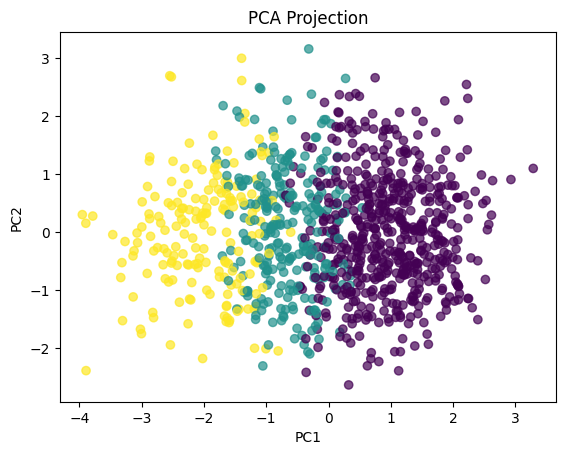

In [141]:
data = apply_pca_to_dataset("/content/student_performance.csv", 2)[0]


В ходе применения PCA размерность датасета была снижена с 4 до 2 признаков, что позволило сохранить 70.1% общей дисперсии системы. Качество кластеризации в проекции оказалось существенно выше, чем в исходном пространстве (индекс Силуэта возрос с 0.128 до 0.195, индекс Калински-Харабаса — с 142.36 до 257.19).

Данный эффект доказывает, что младшие компоненты содержали в себе преимущественно стохастический шум. Алгоритм PCA успешно выступил не только в роли компрессора, но и в роли шумоподавителя данных.

In [133]:
add_noise_and_compare(data, noise_level=0.3)

Исследование влияния шума

1. Сумма всех собственных значений
Без шума:      4.0000
С шумом:       4.3542  (Рост из-за дисперсии шума)

2. Доля информации в главной компоненте:
Без шума:   44.87%
С шумом:    43.18%
Незначительная деградация

3. Изменение спектра:
labmda_1: было    1.795, стало    1.880, дельта    0.085
labmda_2: было    1.008, стало    1.104, дельта    0.096
labmda_3: было    0.992, стало    1.063, дельта    0.071
labmda_4: было    0.205, стало    0.308, дельта    0.102
Шум равномерно увеличил все собственные значения


При проекции центрированных данных $X$ на вектор $w$, мы получаем новый вектор $Xw$. Вычислим дисперсию этой проекции:$$\text{Var}(Xw) = \frac{1}{n-1} (Xw)^T (Xw) = \frac{1}{n-1} w^T X^T X w = w^T \left( \frac{1}{n-1} X^T X \right) w = w^T C w$$

Так как матрица ковариаций $C$ является симметричной и положительно определённой, по спектральной теореме её можно представить в виде:
  $$C = V \Lambda V^T$$где: $V$ — ортогональная матрица ($V^T V = V V^T = I$), столбцы которой являются собственными векторами $v_i$, образующими ортонормированный базис.  $\Lambda$ — диагональная матрица с вещественными неотрицательными собственными значениями $\lambda_i$ на главной диагонали. Упорядочим их по убыванию: $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_m \ge 0$

$$\text{Var}(Xw) = w^T (V \Lambda V^T) w = (V^T w)^T \Lambda (V^T w)$$

Пусть $y = V^T w$

$$||y||^2 = y^T y = (V^T w)^T (V^T w) = w^T V V^T w = w^T I w = w^T w = 1$$

Следовательно, $\sum_{i=1}^{m} y_i^2 = 1$.

Теперь перепишем дисперсию через вектор $y$ и диагональную матрицу $\Lambda$:$$w^T C w = y^T \Lambda y = \sum_{i=1}^{m} \lambda_i y_i^2$$

Нам нужно найти максимум суммы $\sum_{i=1}^{m} \lambda_i y_i^2$ при условии $\sum_{i=1}^{m} y_i^2 = 1$ и $y_i^2 \ge 0$.

$$\sum_{i=1}^{m} \lambda_i y_i^2 \le \sum_{i=1}^{m} \lambda_1 y_i^2 = \lambda_1 \sum_{i=1}^{m} y_i^2 = \lambda_1 \cdot 1 = \lambda_1$$

Равенство (и максимум) достигается тогда и только тогда, когда $y_1^2 = 1$, а все остальные $y_i^2 = 0$ (для $i > 1$).
В векторном виде это означает, что $y = (1, 0, \dots, 0)^T$.

$$w = V \begin{pmatrix} 1 \\ 0 \\ \vdots \\ 0 \end{pmatrix} = v_1$$

Результат умножения матрицы $V$ на такой вектор — это в точности первый столбец матрицы $V$, то есть собственный вектор $v_1$, соответствующий максимальному собственному значению $\lambda_1$.